# MNIST Classification — Neural Network (PyTorch)

## Goal
Build an end-to-end image classification pipeline using a simple feedforward neural network.

## Dataset
MNIST — handwritten digits (0–9)

- 10 classes
- Grayscale images
- Size: 28 × 28

## Problem Type

- Multi-class classification (10 classes)
- Input: Image
- Output: Digit label (0–9)

## Key Decision

- Use a simple Neural Network (Linear layers)
- Flatten image → treat as feature vector

## Data Pipeline

image → tensor → DataLoader → batch

### Transform
- `ToTensor()`
- Converts image to tensor
- Scales pixel values from [0, 255] → [0, 1]

### DataLoader
- Handles batching
- Enables shuffling

## Data Shapes

Images: (batch, channel, height, width)
→ (32, 1, 28, 28)

Labels: (batch,)
→ (32,)

### Interpretation

- 32 → batch size
- 1 → grayscale channel
- 28 × 28 → image size

## Flattening

(1, 28, 28) → (784)

Why?

- Linear layers require vector input
- Converts image to feature vector

Limitation:

- Loses spatial structure
- Treats pixels as independent features

## Model

784 → 128 → 64 → 10

- ReLU activations
- Output layer = 10 (number of classes)

Output:
- Logits (not probabilities)

## Loss Function

CrossEntropyLoss

Why?

- Multi-class classification

Important:

- Do NOT apply softmax manually
- Loss expects raw logits

## Training Loop

Steps per batch:

1. Forward pass
2. Compute loss
3. Zero gradients
4. Backpropagation
5. Update weights

optimizer.zero_grad()
loss.backward()
optimizer.step()

## Evaluation

- Use model.eval()
- Disable gradients using torch.no_grad()

Prediction:

preds = torch.argmax(outputs, dim=1)

Accuracy:

correct / total

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root = "./data", train = True, transform= transform, download = True)
test_dataset = datasets.MNIST(root= "./data", train = False, transform = transform, download = True)

train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = False)

images, labels =  next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([32, 1, 28, 28])
torch.Size([32])


Shape: (batch, channels, height, width)


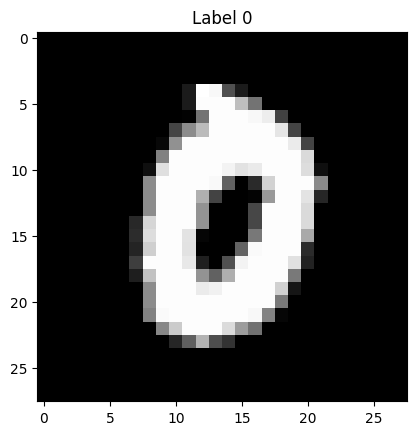

In [2]:
import matplotlib.pyplot as plt

plt.imshow(images[1].squeeze(), cmap= "grey")
plt.title(f"Label {labels[1].item()}")
plt.show()

In [14]:
############ changing the images shape ie, flattening it to input to the Linear layer ###############
images_flat = images.view(32, -1)
print(images_flat.shape)


torch.Size([32, 784])


In [3]:
from torch.nn.modules.activation import ReLU
######### model definition #########

model= nn.Sequential(
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)



In [4]:
######### training #############
for epoch in range(3):

  for images, labels in train_loader:
  # print(images.shape, labels.shape)

    images_flat = images.view(len(labels), -1)
    output = model(images_flat)
    loss = loss_fn(output, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  print(f"epoch {epoch} done")



epoch 0 done
epoch 1 done
epoch 2 done


In [9]:
####### inference ###############
correct = 0
total = 0

with torch.no_grad():
  for images, labels in test_loader:
    images_flat = images.view(len(labels), -1)

    outputs = model(images_flat)
    _, preds = torch.max(outputs, dim = 1)

    correct += (preds ==labels).sum().item()
    total += len(labels)

print("corrects: ", correct)
print("total: ", total)
accuracy = correct/total *100

print("Accuracy: ", accuracy, "%")

corrects:  9611
total:  10000
Accuracy:  96.11 %


## Results

- Accuracy: ~96%

Observation:

- Model learns quickly on MNIST
- Even simple NN performs well

## Key Learnings

- Image data shape: (batch, channel, height, width)
- Need to flatten for linear layers
- CrossEntropyLoss for multi-class problems
- Logits vs probabilities
- Mini-batch training using DataLoader
- Proper evaluation requires full dataset

## Limitations

- Flattening removes spatial structure
- Model does not understand pixel relationships
- Inefficient for image data

## Next Step

Use Convolutional Neural Networks (CNN)

Goal:

- Preserve spatial structure
- Learn local patterns (edges, shapes)
- Improve performance and efficiency